In [ ]:
# ============================================================
# CELL 1 — INSTALL REQUIRED LIBRARIES
# ============================================================

!pip -q install yfinance pandas numpy scipy matplotlib seaborn scikit-learn requests

In [ ]:
# ============================================================
# CELL 2 — IMPORTS & PROJECT CONFIGURATION
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import zscore
from datetime import datetime

# -----------------------------
# Project configuration
# -----------------------------

START_DATE = "2020-01-01"
END_DATE = datetime.today().strftime("%Y-%m-%d")

# Example universe.
# We can expand this substantially later.
TICKERS = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "META",
    "NVDA", "JPM", "V", "MA", "JNJ",
    "PG", "KO", "PEP", "WMT", "COST",
    "HD", "MCD", "DIS", "NFLX", "ADBE"
]

FACTOR_WEIGHTS = {
    "value": 0.25,
    "quality": 0.30,
    "momentum": 0.25,
    "low_volatility": 0.20
}

print(f"Universe size: {len(TICKERS)}")
print(f"Data period: {START_DATE} → {END_DATE}")

Universe size: 20
Data period: 2020-01-01 → 2026-08-29


In [ ]:
# ============================================================
# CELL 3 — DOWNLOAD HISTORICAL MARKET DATA
# ============================================================

def download_price_data(tickers, start, end):
    """
    Download adjusted historical prices from Yahoo Finance.

    Parameters
    ----------
    tickers : list
        List of ticker symbols.
    start : str
        Start date in YYYY-MM-DD format.
    end : str
        End date in YYYY-MM-DD format.

    Returns
    -------
    pd.DataFrame
        Adjusted closing prices.
    """

    try:
        data = yf.download(
            tickers,
            start=start,
            end=end,
            auto_adjust=True,
            progress=False
        )

        if data.empty:
            raise ValueError("No market data was returned.")

        # Handle both single- and multi-ticker responses
        if isinstance(data.columns, pd.MultiIndex):
            prices = data["Close"]
        else:
            prices = data[["Close"]]

        prices = prices.dropna(axis=1, how="all")

        print(f"Successfully downloaded data for {prices.shape[1]} securities.")

        return prices

    except Exception as e:
        print(f"Error downloading market data: {e}")
        return pd.DataFrame()


prices = download_price_data(
    TICKERS,
    START_DATE,
    END_DATE
)

prices.head()

Successfully downloaded data for 20 securities.


Ticker,AAPL,ADBE,AMZN,COST,DIS,GOOGL,HD,JNJ,JPM,KO,MA,MCD,META,MSFT,NFLX,NVDA,PEP,PG,V,WMT
Date,,,,,,,,,,,,,,,,,,,,
2020-01-02,72.271523,334.429993,94.900497,265.326477,143.689240,67.832504,187.322601,121.338539,117.899193,45.141266,291.906708,172.623199,207.953857,151.544250,32.980999,5.963804,110.945145,103.959282,182.092758,36.203289
2020-01-03,71.568924,331.809998,93.748497,265.544952,142.041000,67.477654,186.700058,119.933678,116.343369,44.895000,289.058655,172.012772,206.853500,149.657257,32.590000,5.868347,110.789925,103.260117,180.644608,35.883675
2020-01-06,72.139183,333.709991,95.143997,265.617798,141.216858,69.276215,187.578461,119.784088,116.250824,44.878571,289.828522,173.947144,210.749298,150.044083,33.583000,5.892957,111.214691,103.403320,180.253937,35.810631
2020-01-07,71.799911,333.390015,95.343002,265.198975,141.265366,69.142403,186.350433,120.515602,114.274498,44.533806,288.847046,174.205063,211.205292,148.676041,33.075001,5.964301,109.466614,102.763107,179.777512,35.478848
2020-01-08,72.954910,337.869995,94.598503,268.239319,140.974487,69.634544,189.139023,120.498978,115.165962,44.615891,293.943542,177.024918,213.346481,151.044220,33.925999,5.975486,110.030258,103.201157,182.854996,35.357105


In [ ]:
# ============================================================
# CELL 4 — RETURN & VOLATILITY CALCULATIONS
# ============================================================

daily_returns = prices.pct_change().dropna()

# Annualized volatility
annualized_volatility = daily_returns.std() * np.sqrt(252)

# 12-month momentum
momentum_12m = prices.pct_change(252).iloc[-1]

# 6-month momentum
momentum_6m = prices.pct_change(126).iloc[-1]

# Combined momentum score
momentum_raw = (
    0.70 * momentum_12m +
    0.30 * momentum_6m
)

print("Return calculations complete.")

display(
    pd.DataFrame({
        "12M Momentum": momentum_12m,
        "6M Momentum": momentum_6m,
        "Annualized Volatility": annualized_volatility
    }).sort_values("12M Momentum", ascending=False).head(10)
)

Return calculations complete.


,12M Momentum,6M Momentum,Annualized Volatility
Ticker,,,
GOOGL,0.646529,0.094090,0.325228
JNJ,0.537187,0.081257,0.197516
AAPL,0.369873,0.192904,0.313710
KO,0.330557,0.106564,0.202909
NVDA,0.257068,0.288211,0.519577
JPM,0.206216,0.190931,0.306515
AMZN,0.118453,0.220286,0.357254
V,0.092326,0.190585,0.267393
WMT,0.077166,-0.192782,0.235346


In [ ]:
import pandas as pd
import numpy as np
# ============================================================
# CELL 6 — FACTOR STANDARDIZATION
# ============================================================

def winsorize_series(series, lower=0.05, upper=0.95):
    """
    Reduce the influence of extreme observations.
    """

    low = series.quantile(lower)
    high = series.quantile(upper)

    return series.clip(lower=low, upper=high)


def standardize_factor(series):
    """
    Winsorize and convert a factor into a cross-sectional
    z-score.
    """

    series = winsorize_series(series)

    std = series.std()

    if std == 0 or pd.isna(std):
        return pd.Series(0, index=series.index)

    return (series - series.mean()) / std

# Initialize factor_data with calculated factors from previous steps.
# Placeholder values are used for 'value' and 'quality' as they are not calculated in the provided notebook cells.
# Ensure the index aligns with the tickers for which factors are calculated.
factor_data = pd.DataFrame(index=TICKERS)

# Add 'momentum' factor from the previously calculated momentum_raw
factor_data["momentum"] = momentum_raw

# For 'low_volatility' factor, we want lower volatility to result in a higher score.
# So, we negate the annualized_volatility before standardization.
factor_data["low_volatility"] = -annualized_volatility

# Add placeholder columns for 'value' and 'quality' factors
# In a complete implementation, these would be derived from financial statements.
factor_data["value"] = 0.0  # Placeholder
factor_data["quality"] = 0.0 # Placeholder

for factor in [
    "value",
    "quality",
    "momentum",
    "low_volatility"
]:

    factor_data[f"{factor}_score"] = standardize_factor(
        factor_data[factor]
    )

factor_data.head()

,momentum,low_volatility,value,quality,value_score,quality_score,momentum_score,low_volatility_score
AAPL,0.316782,-0.313710,0.0,0.0,0,0,1.300285,-0.176489
MSFT,0.090780,-0.304354,0.0,0.0,0,0,0.154673,-0.057611
GOOGL,0.480797,-0.325228,0.0,0.0,0,0,1.744562,-0.322833
AMZN,0.149003,-0.357254,0.0,0.0,0,0,0.449806,-0.729726
META,-0.198555,-0.437035,0.0,0.0,0,0,-1.311979,-1.743369


In [ ]:
# ============================================================
# CELL 7 — COMPOSITE QUANTITATIVE SCORE
# ============================================================

factor_data["composite_score"] = (
    FACTOR_WEIGHTS["value"] *
    factor_data["value_score"]

    +

    FACTOR_WEIGHTS["quality"] *
    factor_data["quality_score"]

    +

    FACTOR_WEIGHTS["momentum"] *
    factor_data["momentum_score"]

    +

    FACTOR_WEIGHTS["low_volatility"] *
    factor_data["low_volatility_score"]
)

ranked_stocks = (
    factor_data
    .sort_values("composite_score", ascending=False)
    .copy()
)

ranked_stocks["rank"] = np.arange(1, len(ranked_stocks) + 1)

ranked_stocks[
    [
        "rank",
        "value_score",
        "quality_score",
        "momentum_score",
        "low_volatility_score",
        "composite_score"
    ]
].head(10)

,rank,value_score,quality_score,momentum_score,low_volatility_score,composite_score
JNJ,1,0,0,1.724187,1.234708,0.677988
KO,2,0,0,1.029481,1.231283,0.503627
GOOGL,3,0,0,1.744562,-0.322833,0.371574
AAPL,4,0,0,1.300285,-0.176489,0.289773
JPM,5,0,0,0.716579,-0.085076,0.162130
V,6,0,0,0.311931,0.411981,0.160379
WMT,7,0,0,-0.324851,0.819152,0.082618
PG,8,0,0,-0.721994,1.184751,0.056452
COST,9,0,0,-0.450904,0.824124,0.052099
PEP,10,0,0,-0.607370,0.994350,0.047027


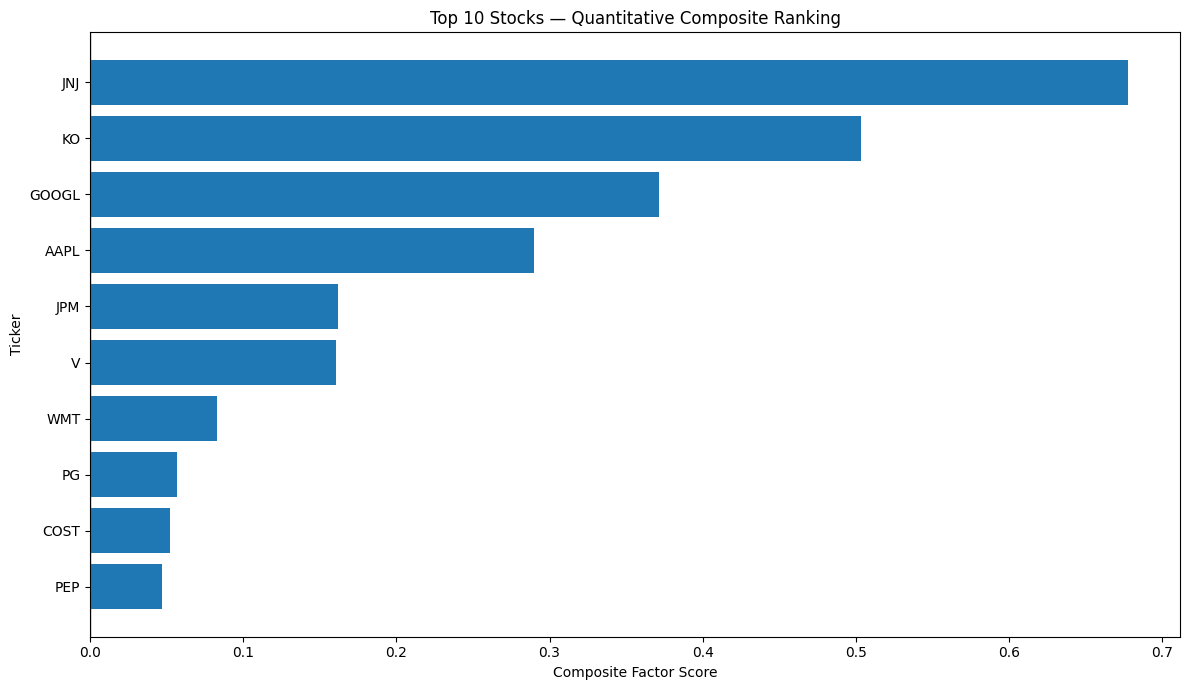

In [ ]:
# ============================================================
# CELL 8 — TOP 10 STOCK RANKINGS
# ============================================================

top_10 = ranked_stocks.head(10).sort_values(
    "composite_score"
)

plt.figure(figsize=(12, 7))

plt.barh(
    top_10.index,
    top_10["composite_score"]
)

plt.xlabel("Composite Factor Score")
plt.ylabel("Ticker")
plt.title("Top 10 Stocks — Quantitative Composite Ranking")

plt.axvline(
    0,
    linewidth=1
)

plt.tight_layout()
plt.show()

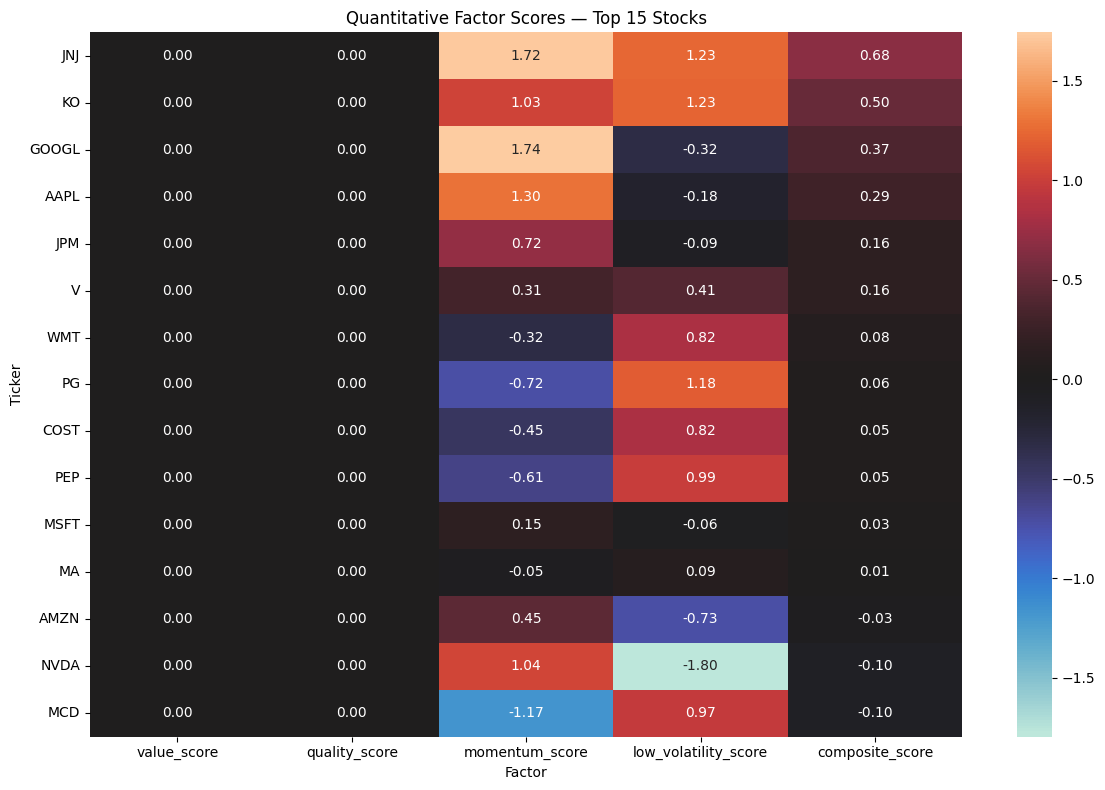

In [ ]:
# ============================================================
# CELL 9 — FACTOR SCORE HEATMAP
# ============================================================

heatmap_data = ranked_stocks.head(15)[
    [
        "value_score",
        "quality_score",
        "momentum_score",
        "low_volatility_score",
        "composite_score"
    ]
]

plt.figure(figsize=(12, 8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    center=0
)

plt.title("Quantitative Factor Scores — Top 15 Stocks")
plt.xlabel("Factor")
plt.ylabel("Ticker")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 10 — TOP-10 EQUAL-WEIGHT PORTFOLIO
# ============================================================

TOP_N = 10

selected_stocks = ranked_stocks.head(TOP_N).index.tolist()

weights = pd.Series(
    1 / TOP_N,
    index=selected_stocks
)

portfolio_returns = (
    daily_returns[selected_stocks]
    .mul(weights, axis=1)
    .sum(axis=1)
)

print("Selected securities:")
print(selected_stocks)

print("\nPortfolio weights:")
display(weights.to_frame("Weight"))

Selected securities:
['JNJ', 'KO', 'GOOGL', 'AAPL', 'JPM', 'V', 'WMT', 'PG', 'COST', 'PEP']

Portfolio weights:


,Weight
JNJ,0.1
KO,0.1
GOOGL,0.1
AAPL,0.1
JPM,0.1
V,0.1
WMT,0.1
PG,0.1
COST,0.1
PEP,0.1


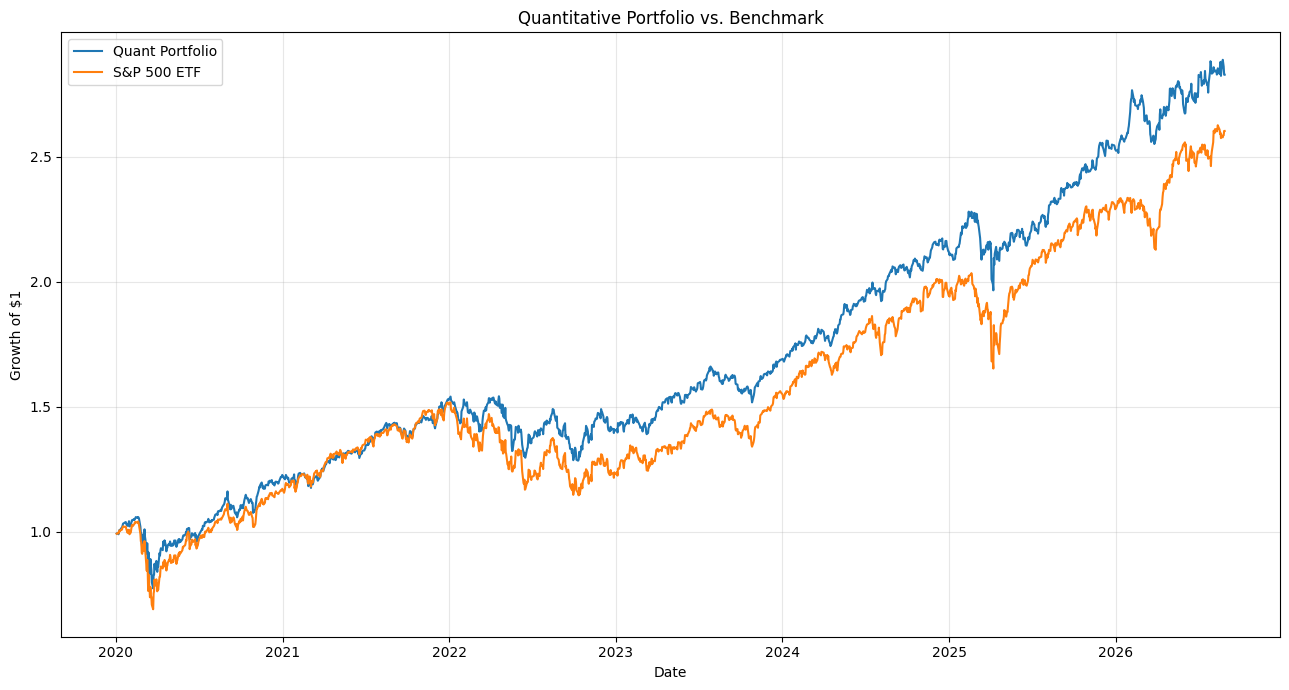

In [ ]:
# ============================================================
# CELL 11 — SIMPLE HISTORICAL BACKTEST
# ============================================================

cumulative_portfolio = (
    1 + portfolio_returns
).cumprod()

benchmark = yf.download(
    "SPY",
    start=START_DATE,
    end=END_DATE,
    auto_adjust=True,
    progress=False
)["Close"]

benchmark_returns = benchmark.pct_change().dropna()

cumulative_benchmark = (
    1 + benchmark_returns
).cumprod()

plt.figure(figsize=(13, 7))

plt.plot(
    cumulative_portfolio,
    label="Quant Portfolio"
)

plt.plot(
    cumulative_benchmark,
    label="S&P 500 ETF"
)

plt.title("Quantitative Portfolio vs. Benchmark")
plt.xlabel("Date")
plt.ylabel("Growth of $1")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# CELL 12 — PERFORMANCE ANALYTICS
# ============================================================

def calculate_performance_metrics(returns):
    """
    Calculate standard portfolio performance metrics.
    """

    returns = returns.dropna()

    if len(returns) == 0:
        return {}

    total_return = (1 + returns).prod() - 1

    years = len(returns) / 252

    cagr = (
        (1 + total_return) ** (1 / years)
        - 1
    )

    volatility = returns.std() * np.sqrt(252)

    sharpe = (
        returns.mean() / returns.std()
    ) * np.sqrt(252)

    cumulative = (1 + returns).cumprod()

    rolling_max = cumulative.cummax()

    drawdown = (
        cumulative / rolling_max
    ) - 1

    max_drawdown = drawdown.min()

    return {
        "Total Return": total_return,
        "CAGR": cagr,
        "Annualized Volatility": volatility,
        "Sharpe Ratio": sharpe,
        "Maximum Drawdown": max_drawdown
    }


portfolio_metrics = calculate_performance_metrics(
    portfolio_returns
)

benchmark_metrics = calculate_performance_metrics(
    benchmark_returns
)

comparison = pd.DataFrame({
    "Quant Portfolio": portfolio_metrics,
    "SPY": benchmark_metrics
})

display(comparison)

,Quant Portfolio,SPY
Total Return,1.828807,Ticker SPY 1.603965 dtype: float64
CAGR,0.169673,Ticker SPY 0.155164 dtype: float64
Annualized Volatility,0.173416,Ticker SPY 0.201452 dtype: float64
Sharpe Ratio,0.990694,Ticker SPY 0.817172 dtype: float64
Maximum Drawdown,-0.269425,Ticker SPY -0.337173 dtype: float64


In [ ]:
## VERSION 2 — FUNDAMENTAL DATA & REAL FACTOR MODEL

In [ ]:
### Cell 13 — Fundamental Data Configuration

In [21]:
# ============================================================
# CELL 13 — FUNDAMENTAL DATA API CONFIGURATION
# ============================================================

import os
import requests
import pandas as pd
import numpy as np

# ------------------------------------------------------------
# LOAD FMP API KEY FROM GOOGLE COLAB SECRETS
# ------------------------------------------------------------

try:
    from google.colab import userdata

    FMP_API_KEY = userdata.get("FMP_API_KEY")

    if FMP_API_KEY:
        print("FMP API key detected successfully.")
    else:
        print("FMP API key is empty.")

except Exception as e:
    print("FMP API key not detected.")
    print("Make sure you created a Colab Secret named exactly:")
    print("FMP_API_KEY")

FMP API key detected successfully.


In [22]:
# ============================================================
# CELL 14 — TEST FMP API CONNECTION
# ============================================================

test_url = "https://financialmodelingprep.com/stable/profile"
params = {
    "symbol": "AAPL",
    "apikey": FMP_API_KEY
}

response = requests.get(test_url, params=params)

print("Status code:", response.status_code)
print("Response:")
print(response.text[:1000])

Status code: 200
Response:
[
  {
    "symbol": "AAPL",
    "price": 319.7,
    "marketCap": 4695547713200,
    "beta": 1.086,
    "lastDividend": 1.06,
    "range": "225.95-344.57",
    "change": 5.12,
    "changePercentage": 1.62757,
    "volume": 38500185,
    "averageVolume": 52898381,
    "companyName": "Apple Inc.",
    "currency": "USD",
    "cik": "0000320193",
    "isin": "US0378331005",
    "cusip": "037833100",
    "exchangeFullName": "NASDAQ Global Select",
    "exchange": "NASDAQ",
    "industry": "Consumer Electronics",
    "website": "https://www.apple.com",
    "description": "Apple Inc. is a global technology corporation that specializes in the conceptualization, production, and sale of a diverse suite of electronic devices. Its comprehensive hardware lineup features the well-known iPhone smartphones, Mac personal computers, and versatile iPad tablets. The company also supplies a range of wearables, smart home products, and accessories, including AirPods, Apple TV, Appl

In [23]:
# ============================================================
# CELL 15 — PULL INCOME STATEMENT DATA
# ============================================================

income_url = "https://financialmodelingprep.com/stable/income-statement"

params = {
    "symbol": "AAPL",
    "apikey": FMP_API_KEY,
    "limit": 5
}

response = requests.get(income_url, params=params)

print("Status code:", response.status_code)

income_data = response.json()

print("Number of periods returned:", len(income_data))

# Display the data as a dataframe
income_df = pd.DataFrame(income_data)

income_df.head()

Status code: 200
Number of periods returned: 5


,date,symbol,reportedCurrency,cik,filingDate,acceptedDate,fiscalYear,period,revenue,costOfRevenue,...,netIncomeFromContinuingOperations,netIncomeFromDiscontinuedOperations,otherAdjustmentsToNetIncome,netIncome,netIncomeDeductions,bottomLineNetIncome,eps,epsDiluted,weightedAverageShsOut,weightedAverageShsOutDil
0,2025-09-27,AAPL,USD,0000320193,2025-10-31,2025-10-31 06:01:26,2025,FY,416161000000,220960000000,...,112010000000,0,0,112010000000,0,112010000000,7.49,7.46,14948500000,15004697000
1,2024-09-28,AAPL,USD,0000320193,2024-11-01,2024-11-01 06:01:36,2024,FY,391035000000,210352000000,...,93736000000,0,0,93736000000,0,93736000000,6.11,6.08,15343783000,15408095000
2,2023-09-30,AAPL,USD,0000320193,2023-11-03,2023-11-02 18:08:27,2023,FY,383285000000,214137000000,...,96995000000,0,0,96995000000,0,96995000000,6.16,6.13,15744231000,15812547000
3,2022-09-24,AAPL,USD,0000320193,2022-10-28,2022-10-27 18:01:14,2022,FY,394328000000,223546000000,...,99803000000,0,0,99803000000,0,99803000000,6.15,6.11,16215963000,16325819000
4,2021-09-25,AAPL,USD,0000320193,2021-10-29,2021-10-28 18:04:28,2021,FY,365817000000,212981000000,...,94680000000,0,0,94680000000,0,94680000000,5.67,5.61,16701272000,16864919000


In [24]:
# ============================================================
# CELL 16 — CLEAN FUNDAMENTAL DATA
# ============================================================

# Select the key financial metrics we want to analyze
fundamental_df = income_df[
    [
        "date",
        "fiscalYear",
        "revenue",
        "grossProfit",
        "operatingIncome",
        "netIncome",
        "eps",
        "epsDiluted",
        "costOfRevenue",
        "researchAndDevelopmentExpenses",
        "sellingGeneralAndAdministrativeExpenses"
    ]
].copy()

# Convert dollar figures into billions for easier analysis
money_columns = [
    "revenue",
    "grossProfit",
    "operatingIncome",
    "netIncome",
    "costOfRevenue",
    "researchAndDevelopmentExpenses",
    "sellingGeneralAndAdministrativeExpenses"
]

for column in money_columns:
    fundamental_df[column] = fundamental_df[column] / 1_000_000_000

# Rename columns to make them easier to read
fundamental_df = fundamental_df.rename(
    columns={
        "date": "Date",
        "fiscalYear": "Fiscal Year",
        "revenue": "Revenue ($B)",
        "grossProfit": "Gross Profit ($B)",
        "operatingIncome": "Operating Income ($B)",
        "netIncome": "Net Income ($B)",
        "eps": "EPS",
        "epsDiluted": "Diluted EPS",
        "costOfRevenue": "Cost of Revenue ($B)",
        "researchAndDevelopmentExpenses": "R&D Expense ($B)",
        "sellingGeneralAndAdministrativeExpenses": "SG&A Expense ($B)"
    }
)

# Display the cleaned dataset
fundamental_df# ============================================================
# CELL 16 — CLEAN FUNDAMENTAL DATA
# ============================================================

# Select the key financial metrics we want to analyze
fundamental_df = income_df[
    [
        "date",
        "fiscalYear",
        "revenue",
        "grossProfit",
        "operatingIncome",
        "netIncome",
        "eps",
        "epsDiluted",
        "costOfRevenue",
        "researchAndDevelopmentExpenses",
        "sellingGeneralAndAdministrativeExpenses"
    ]
].copy()

# Convert dollar figures into billions for easier analysis
money_columns = [
    "revenue",
    "grossProfit",
    "operatingIncome",
    "netIncome",
    "costOfRevenue",
    "researchAndDevelopmentExpenses",
    "sellingGeneralAndAdministrativeExpenses"
]

for column in money_columns:
    fundamental_df[column] = fundamental_df[column] / 1_000_000_000

# Rename columns to make them easier to read
fundamental_df = fundamental_df.rename(
    columns={
        "date": "Date",
        "fiscalYear": "Fiscal Year",
        "revenue": "Revenue ($B)",
        "grossProfit": "Gross Profit ($B)",
        "operatingIncome": "Operating Income ($B)",
        "netIncome": "Net Income ($B)",
        "eps": "EPS",
        "epsDiluted": "Diluted EPS",
        "costOfRevenue": "Cost of Revenue ($B)",
        "researchAndDevelopmentExpenses": "R&D Expense ($B)",
        "sellingGeneralAndAdministrativeExpenses": "SG&A Expense ($B)"
    }
)

# Display the cleaned dataset
fundamental_df

,Date,Fiscal Year,Revenue ($B),Gross Profit ($B),Operating Income ($B),Net Income ($B),EPS,Diluted EPS,Cost of Revenue ($B),R&D Expense ($B),SG&A Expense ($B)
0,2025-09-27,2025,416.161,195.201,133.050,112.010,7.49,7.46,220.960,34.550,27.601
1,2024-09-28,2024,391.035,180.683,123.216,93.736,6.11,6.08,210.352,31.370,26.097
2,2023-09-30,2023,383.285,169.148,114.301,96.995,6.16,6.13,214.137,29.915,24.932
3,2022-09-24,2022,394.328,170.782,119.437,99.803,6.15,6.11,223.546,26.251,25.094
4,2021-09-25,2021,365.817,152.836,108.949,94.680,5.67,5.61,212.981,21.914,21.973


In [25]:
# ============================================================
# CELL 17 — CALCULATE FUNDAMENTAL METRICS
# ============================================================

# Sort from oldest to newest so growth calculations work correctly
fundamental_df = fundamental_df.sort_values("Fiscal Year").reset_index(drop=True)

# Revenue growth
fundamental_df["Revenue Growth (%)"] = (
    fundamental_df["Revenue ($B)"].pct_change() * 100
)

# Net income growth
fundamental_df["Net Income Growth (%)"] = (
    fundamental_df["Net Income ($B)"].pct_change() * 100
)

# EPS growth
fundamental_df["EPS Growth (%)"] = (
    fundamental_df["EPS"].pct_change() * 100
)

# Gross profit margin
fundamental_df["Gross Margin (%)"] = (
    fundamental_df["Gross Profit ($B)"]
    / fundamental_df["Revenue ($B)"]
    * 100
)

# Operating profit margin
fundamental_df["Operating Margin (%)"] = (
    fundamental_df["Operating Income ($B)"]
    / fundamental_df["Revenue ($B)"]
    * 100
)

# Net profit margin
fundamental_df["Net Margin (%)"] = (
    fundamental_df["Net Income ($B)"]
    / fundamental_df["Revenue ($B)"]
    * 100
)

# Display the results
fundamental_df.round(2)

,Date,Fiscal Year,Revenue ($B),Gross Profit ($B),Operating Income ($B),Net Income ($B),EPS,Diluted EPS,Cost of Revenue ($B),R&D Expense ($B),SG&A Expense ($B),Revenue Growth (%),Net Income Growth (%),EPS Growth (%),Gross Margin (%),Operating Margin (%),Net Margin (%)
0,2021-09-25,2021,365.82,152.84,108.95,94.68,5.67,5.61,212.98,21.91,21.97,NaN,NaN,NaN,41.78,29.78,25.88
1,2022-09-24,2022,394.33,170.78,119.44,99.80,6.15,6.11,223.55,26.25,25.09,7.79,5.41,8.47,43.31,30.29,25.31
2,2023-09-30,2023,383.28,169.15,114.30,97.00,6.16,6.13,214.14,29.92,24.93,-2.80,-2.81,0.16,44.13,29.82,25.31
3,2024-09-28,2024,391.04,180.68,123.22,93.74,6.11,6.08,210.35,31.37,26.10,2.02,-3.36,-0.81,46.21,31.51,23.97
4,2025-09-27,2025,416.16,195.20,133.05,112.01,7.49,7.46,220.96,34.55,27.60,6.43,19.50,22.59,46.91,31.97,26.92


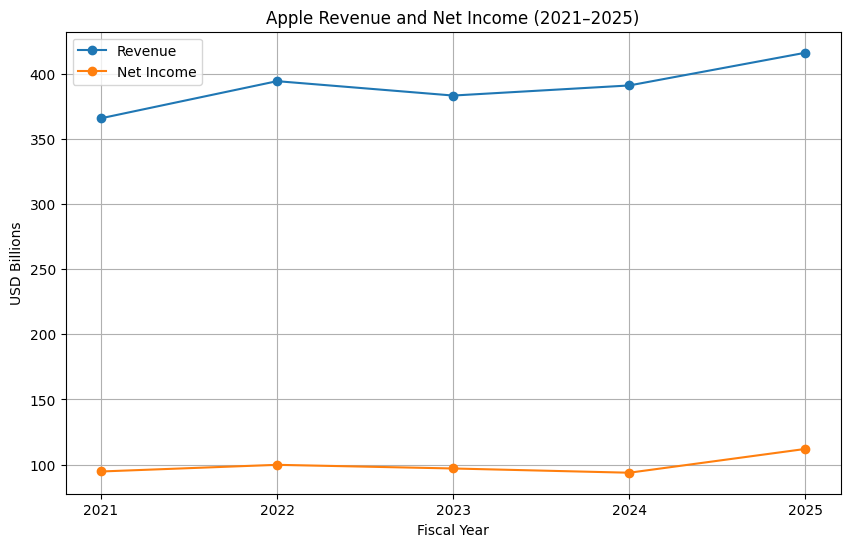

In [26]:
# ============================================================
# CELL 18 — REVENUE AND NET INCOME TREND
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    fundamental_df["Fiscal Year"],
    fundamental_df["Revenue ($B)"],
    marker="o",
    label="Revenue"
)

plt.plot(
    fundamental_df["Fiscal Year"],
    fundamental_df["Net Income ($B)"],
    marker="o",
    label="Net Income"
)

plt.title("Apple Revenue and Net Income (2021–2025)")
plt.xlabel("Fiscal Year")
plt.ylabel("USD Billions")
plt.legend()
plt.grid(True)

plt.show()

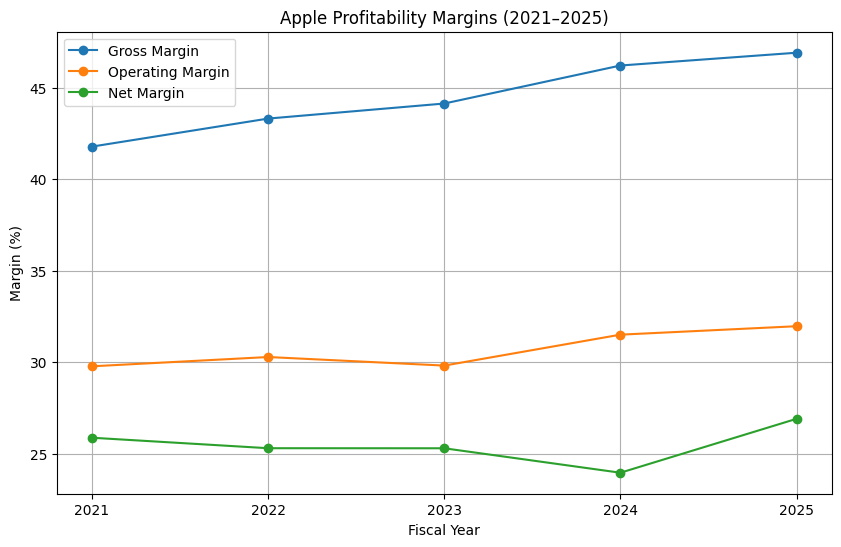

In [27]:
# ============================================================
# CELL 19 — PROFITABILITY MARGINS
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    fundamental_df["Fiscal Year"],
    fundamental_df["Gross Margin (%)"],
    marker="o",
    label="Gross Margin"
)

plt.plot(
    fundamental_df["Fiscal Year"],
    fundamental_df["Operating Margin (%)"],
    marker="o",
    label="Operating Margin"
)

plt.plot(
    fundamental_df["Fiscal Year"],
    fundamental_df["Net Margin (%)"],
    marker="o",
    label="Net Margin"
)

plt.title("Apple Profitability Margins (2021–2025)")
plt.xlabel("Fiscal Year")
plt.ylabel("Margin (%)")
plt.legend()
plt.grid(True)

plt.show()

In [28]:
# ============================================================
# CELL 20 — PULL BALANCE SHEET DATA
# ============================================================

balance_url = "https://financialmodelingprep.com/stable/balance-sheet-statement"

params = {
    "symbol": "AAPL",
    "apikey": FMP_API_KEY,
    "limit": 5
}

response = requests.get(balance_url, params=params)

print("Status code:", response.status_code)

balance_data = response.json()

print("Number of periods returned:", len(balance_data))

balance_df = pd.DataFrame(balance_data)

balance_df.head()

Status code: 200
Number of periods returned: 5


,date,symbol,reportedCurrency,cik,filingDate,acceptedDate,fiscalYear,period,cashAndCashEquivalents,shortTermInvestments,...,additionalPaidInCapital,accumulatedOtherComprehensiveIncomeLoss,otherTotalStockholdersEquity,totalStockholdersEquity,totalEquity,minorityInterest,totalLiabilitiesAndTotalEquity,totalInvestments,totalDebt,netDebt
0,2025-09-27,AAPL,USD,0000320193,2025-10-31,2025-10-31 06:01:26,2025,FY,35934000000,18763000000,...,0,-5571000000,0,73733000000,73733000000,0,359241000000,96486000000,112377000000,76443000000
1,2024-09-28,AAPL,USD,0000320193,2024-11-01,2024-11-01 06:01:36,2024,FY,29943000000,35228000000,...,0,-7172000000,0,56950000000,56950000000,0,364980000000,126707000000,119059000000,89116000000
2,2023-09-30,AAPL,USD,0000320193,2023-11-03,2023-11-02 18:08:27,2023,FY,29965000000,31590000000,...,0,-11452000000,0,62146000000,62146000000,0,352583000000,132134000000,123930000000,93965000000
3,2022-09-24,AAPL,USD,0000320193,2022-10-28,2022-10-27 18:01:14,2022,FY,23646000000,24658000000,...,0,-11109000000,0,50672000000,50672000000,0,352755000000,145463000000,132480000000,108834000000
4,2021-09-25,AAPL,USD,0000320193,2021-10-29,2021-10-28 18:04:28,2021,FY,34940000000,27699000000,...,0,163000000,0,63090000000,63090000000,0,351002000000,155576000000,136522000000,101582000000


In [29]:
# ============================================================
# CELL 21 — CLEAN BALANCE SHEET DATA
# ============================================================

balance_clean_df = balance_df[
    [
        "date",
        "fiscalYear",
        "cashAndCashEquivalents",
        "shortTermInvestments",
        "totalCurrentAssets",
        "totalAssets",
        "totalCurrentLiabilities",
        "totalLiabilities",
        "totalStockholdersEquity",
        "totalDebt",
        "netDebt",
        "inventory",
        "netReceivables"
    ]
].copy()

# Convert dollar figures into billions
balance_money_columns = [
    "cashAndCashEquivalents",
    "shortTermInvestments",
    "totalCurrentAssets",
    "totalAssets",
    "totalCurrentLiabilities",
    "totalLiabilities",
    "totalStockholdersEquity",
    "totalDebt",
    "netDebt",
    "inventory",
    "netReceivables"
]

for column in balance_money_columns:
    balance_clean_df[column] = balance_clean_df[column] / 1_000_000_000

# Rename columns
balance_clean_df = balance_clean_df.rename(
    columns={
        "date": "Date",
        "fiscalYear": "Fiscal Year",
        "cashAndCashEquivalents": "Cash & Equivalents ($B)",
        "shortTermInvestments": "Short-Term Investments ($B)",
        "totalCurrentAssets": "Current Assets ($B)",
        "totalAssets": "Total Assets ($B)",
        "totalCurrentLiabilities": "Current Liabilities ($B)",
        "totalLiabilities": "Total Liabilities ($B)",
        "totalStockholdersEquity": "Shareholders' Equity ($B)",
        "totalDebt": "Total Debt ($B)",
        "netDebt": "Net Debt ($B)",
        "inventory": "Inventory ($B)",
        "netReceivables": "Receivables ($B)"
    }
)

# Sort chronologically
balance_clean_df = balance_clean_df.sort_values(
    "Fiscal Year"
).reset_index(drop=True)

# Display cleaned data
balance_clean_df.round(2)

,Date,Fiscal Year,Cash & Equivalents ($B),Short-Term Investments ($B),Current Assets ($B),Total Assets ($B),Current Liabilities ($B),Total Liabilities ($B),Shareholders' Equity ($B),Total Debt ($B),Net Debt ($B),Inventory ($B),Receivables ($B)
0,2021-09-25,2021,34.94,27.70,134.84,351.00,125.48,287.91,63.09,136.52,101.58,6.58,51.51
1,2022-09-24,2022,23.65,24.66,135.40,352.76,153.98,302.08,50.67,132.48,108.83,4.95,60.93
2,2023-09-30,2023,29.96,31.59,143.57,352.58,145.31,290.44,62.15,123.93,93.96,6.33,60.98
3,2024-09-28,2024,29.94,35.23,152.99,364.98,176.39,308.03,56.95,119.06,89.12,7.29,66.24
4,2025-09-27,2025,35.93,18.76,147.96,359.24,165.63,285.51,73.73,112.38,76.44,5.72,72.96


In [30]:
# ============================================================
# CELL 22 — BALANCE SHEET RATIOS
# ============================================================

# Current ratio
balance_clean_df["Current Ratio"] = (
    balance_clean_df["Current Assets ($B)"]
    / balance_clean_df["Current Liabilities ($B)"]
)

# Debt-to-assets ratio
balance_clean_df["Debt-to-Assets (%)"] = (
    balance_clean_df["Total Debt ($B)"]
    / balance_clean_df["Total Assets ($B)"]
    * 100
)

# Debt-to-equity ratio
balance_clean_df["Debt-to-Equity"] = (
    balance_clean_df["Total Debt ($B)"]
    / balance_clean_df["Shareholders' Equity ($B)"]
)

# Net debt-to-assets ratio
balance_clean_df["Net Debt-to-Assets (%)"] = (
    balance_clean_df["Net Debt ($B)"]
    / balance_clean_df["Total Assets ($B)"]
    * 100
)

# Cash + short-term investments
balance_clean_df["Cash + Investments ($B)"] = (
    balance_clean_df["Cash & Equivalents ($B)"]
    + balance_clean_df["Short-Term Investments ($B)"]
)

# Display key ratios
ratio_columns = [
    "Fiscal Year",
    "Current Ratio",
    "Debt-to-Assets (%)",
    "Debt-to-Equity",
    "Net Debt-to-Assets (%)",
    "Cash + Investments ($B)"
]

balance_clean_df[ratio_columns].round(2)

,Fiscal Year,Current Ratio,Debt-to-Assets (%),Debt-to-Equity,Net Debt-to-Assets (%),Cash + Investments ($B)
0,2021,1.07,38.89,2.16,28.94,62.64
1,2022,0.88,37.56,2.61,30.85,48.30
2,2023,0.99,35.15,1.99,26.65,61.56
3,2024,0.87,32.62,2.09,24.42,65.17
4,2025,0.89,31.28,1.52,21.28,54.70


In [31]:
# ============================================================
# CELL 23 — PULL CASH FLOW DATA
# ============================================================

cashflow_url = "https://financialmodelingprep.com/stable/cash-flow-statement"

params = {
    "symbol": "AAPL",
    "apikey": FMP_API_KEY,
    "limit": 5
}

response = requests.get(cashflow_url, params=params)

print("Status code:", response.status_code)

cashflow_data = response.json()

print("Number of periods returned:", len(cashflow_data))

cashflow_df = pd.DataFrame(cashflow_data)

cashflow_df.head()

Status code: 200
Number of periods returned: 5


,date,symbol,reportedCurrency,cik,filingDate,acceptedDate,fiscalYear,period,netIncome,depreciationAndAmortization,...,netCashProvidedByFinancingActivities,effectOfForexChangesOnCash,netChangeInCash,cashAtEndOfPeriod,cashAtBeginningOfPeriod,operatingCashFlow,capitalExpenditure,freeCashFlow,incomeTaxesPaid,interestPaid
0,2025-09-27,AAPL,USD,0000320193,2025-10-31,2025-10-31 06:01:26,2025,FY,112010000000,11698000000,...,-120686000000,0,5991000000,35934000000,29943000000,111482000000,-12715000000,98767000000,43369000000,0
1,2024-09-28,AAPL,USD,0000320193,2024-11-01,2024-11-01 06:01:36,2024,FY,93736000000,11445000000,...,-121983000000,0,-794000000,29943000000,30737000000,118254000000,-9447000000,108807000000,26102000000,0
2,2023-09-30,AAPL,USD,0000320193,2023-11-03,2023-11-02 18:08:27,2023,FY,96995000000,11519000000,...,-108488000000,0,5760000000,30737000000,24977000000,110543000000,-10959000000,99584000000,18679000000,3803000000
3,2022-09-24,AAPL,USD,0000320193,2022-10-28,2022-10-27 18:01:14,2022,FY,99803000000,11104000000,...,-110749000000,0,-10952000000,24977000000,35929000000,122151000000,-10708000000,111443000000,19573000000,2865000000
4,2021-09-25,AAPL,USD,0000320193,2021-10-29,2021-10-28 18:04:28,2021,FY,94680000000,11284000000,...,-93353000000,0,-3860000000,35929000000,39789000000,104038000000,-11085000000,92953000000,25385000000,2687000000


In [33]:
# ============================================================
# CELL 24 — CLEAN CASH FLOW DATA
# ============================================================

# First, check the exact column names returned by FMP
print("Available cash-flow columns:")
print(cashflow_df.columns.tolist())

# Select the core cash-flow metrics
cashflow_clean_df = cashflow_df[
    [
        "date",
        "fiscalYear",
        "netIncome",
        "depreciationAndAmortization",
        "operatingCashFlow",
        "capitalExpenditure",
        "freeCashFlow",
        "netCashProvidedByInvestingActivities",
        "netCashProvidedByFinancingActivities",
        "netChangeInCash"
    ]
].copy()

# Convert dollar figures into billions
cashflow_money_columns = [
    "netIncome",
    "depreciationAndAmortization",
    "operatingCashFlow",
    "capitalExpenditure",
    "freeCashFlow",
    "netCashProvidedByInvestingActivities",
    "netCashProvidedByFinancingActivities",
    "netChangeInCash"
]

for column in cashflow_money_columns:
    cashflow_clean_df[column] = cashflow_clean_df[column] / 1_000_000_000

# Rename columns
cashflow_clean_df = cashflow_clean_df.rename(
    columns={
        "date": "Date",
        "fiscalYear": "Fiscal Year",
        "netIncome": "Net Income ($B)",
        "depreciationAndAmortization": "D&A ($B)",
        "operatingCashFlow": "Operating Cash Flow ($B)",
        "capitalExpenditure": "Capital Expenditure ($B)",
        "freeCashFlow": "Free Cash Flow ($B)",
        "netCashProvidedByInvestingActivities": "Investing Cash Flow ($B)",
        "netCashProvidedByFinancingActivities": "Financing Cash Flow ($B)",
        "netChangeInCash": "Change in Cash ($B)"
    }
)

# Sort chronologically
cashflow_clean_df = cashflow_clean_df.sort_values(
    "Fiscal Year"
).reset_index(drop=True)

# Display cleaned data
cashflow_clean_df.round(2)

Available cash-flow columns:
['date', 'symbol', 'reportedCurrency', 'cik', 'filingDate', 'acceptedDate', 'fiscalYear', 'period', 'netIncome', 'depreciationAndAmortization', 'deferredIncomeTax', 'stockBasedCompensation', 'changeInWorkingCapital', 'accountsReceivables', 'inventory', 'accountsPayables', 'otherWorkingCapital', 'otherNonCashItems', 'netCashProvidedByOperatingActivities', 'investmentsInPropertyPlantAndEquipment', 'acquisitionsNet', 'purchasesOfInvestments', 'salesMaturitiesOfInvestments', 'otherInvestingActivities', 'netCashProvidedByInvestingActivities', 'netDebtIssuance', 'longTermNetDebtIssuance', 'shortTermNetDebtIssuance', 'netStockIssuance', 'netCommonStockIssuance', 'commonStockIssuance', 'commonStockRepurchased', 'netPreferredStockIssuance', 'netDividendsPaid', 'commonDividendsPaid', 'preferredDividendsPaid', 'otherFinancingActivities', 'netCashProvidedByFinancingActivities', 'effectOfForexChangesOnCash', 'netChangeInCash', 'cashAtEndOfPeriod', 'cashAtBeginningOfPeri

,Date,Fiscal Year,Net Income ($B),D&A ($B),Operating Cash Flow ($B),Capital Expenditure ($B),Free Cash Flow ($B),Investing Cash Flow ($B),Financing Cash Flow ($B),Change in Cash ($B)
0,2021-09-25,2021,94.68,11.28,104.04,-11.08,92.95,-14.54,-93.35,-3.86
1,2022-09-24,2022,99.80,11.10,122.15,-10.71,111.44,-22.35,-110.75,-10.95
2,2023-09-30,2023,97.00,11.52,110.54,-10.96,99.58,3.70,-108.49,5.76
3,2024-09-28,2024,93.74,11.44,118.25,-9.45,108.81,2.94,-121.98,-0.79
4,2025-09-27,2025,112.01,11.70,111.48,-12.72,98.77,15.20,-120.69,5.99


In [35]:
# ============================================================
# CELL 25 — CASH FLOW METRICS
# ============================================================

# Operating cash flow growth
cashflow_clean_df["OCF Growth (%)"] = (
    cashflow_clean_df["Operating Cash Flow ($B)"].pct_change() * 100
)

# Free cash flow growth
cashflow_clean_df["FCF Growth (%)"] = (
    cashflow_clean_df["Free Cash Flow ($B)"].pct_change() * 100
)

# Free cash flow margin
cashflow_clean_df["FCF Margin (%)"] = (
    cashflow_clean_df["Free Cash Flow ($B)"]
    / fundamental_df["Revenue ($B)"]
    * 100
)

# Operating cash flow margin
cashflow_clean_df["OCF Margin (%)"] = (
    cashflow_clean_df["Operating Cash Flow ($B)"]
    / fundamental_df["Revenue ($B)"]
    * 100
)

# Display metrics
cashflow_clean_df.round(2)

,Date,Fiscal Year,Net Income ($B),D&A ($B),Operating Cash Flow ($B),Capital Expenditure ($B),Free Cash Flow ($B),Investing Cash Flow ($B),Financing Cash Flow ($B),Change in Cash ($B),OCF Growth (%),FCF Growth (%),FCF Margin (%),OCF Margin (%)
0,2021-09-25,2021,94.68,11.28,104.04,-11.08,92.95,-14.54,-93.35,-3.86,NaN,NaN,25.41,28.44
1,2022-09-24,2022,99.80,11.10,122.15,-10.71,111.44,-22.35,-110.75,-10.95,17.41,19.89,28.26,30.98
2,2023-09-30,2023,97.00,11.52,110.54,-10.96,99.58,3.70,-108.49,5.76,-9.50,-10.64,25.98,28.84
3,2024-09-28,2024,93.74,11.44,118.25,-9.45,108.81,2.94,-121.98,-0.79,6.98,9.26,27.83,30.24
4,2025-09-27,2025,112.01,11.70,111.48,-12.72,98.77,15.20,-120.69,5.99,-5.73,-9.23,23.73,26.79


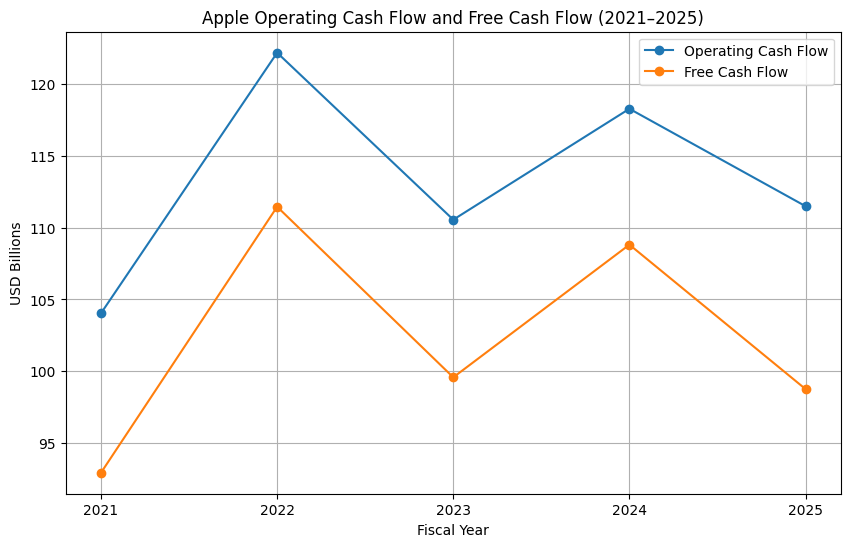

In [36]:
# ============================================================
# CELL 26 — FREE CASH FLOW TREND
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    cashflow_clean_df["Fiscal Year"],
    cashflow_clean_df["Operating Cash Flow ($B)"],
    marker="o",
    label="Operating Cash Flow"
)

plt.plot(
    cashflow_clean_df["Fiscal Year"],
    cashflow_clean_df["Free Cash Flow ($B)"],
    marker="o",
    label="Free Cash Flow"
)

plt.title("Apple Operating Cash Flow and Free Cash Flow (2021–2025)")
plt.xlabel("Fiscal Year")
plt.ylabel("USD Billions")
plt.legend()
plt.grid(True)

plt.show()

In [37]:
# ============================================================
# CELL 27 — HISTORICAL STOCK PRICE DATA
# ============================================================

historical_url = "https://financialmodelingprep.com/stable/historical-price-eod/full"

params = {
    "symbol": "AAPL",
    "apikey": FMP_API_KEY,
    "from": "2021-01-01",
    "to": "2025-12-31"
}

response = requests.get(historical_url, params=params)

print("Status code:", response.status_code)

historical_data = response.json()

print("Number of trading observations:", len(historical_data))

historical_df = pd.DataFrame(historical_data)

historical_df.head()

Status code: 200
Number of trading observations: 1255


,symbol,date,open,high,low,close,volume,change,changePercent,vwap
0,AAPL,2025-12-31,273.06,273.68,271.75,271.86,27293639,-1.20,-0.43946,272.5875
1,AAPL,2025-12-30,272.81,274.08,272.28,273.08,22139617,0.27,0.09897,273.0625
2,AAPL,2025-12-29,272.69,274.36,272.35,273.76,23715213,1.07,0.39239,273.2900
3,AAPL,2025-12-26,274.16,275.37,272.86,273.40,21521802,-0.76,-0.27721,273.9475
4,AAPL,2025-12-24,272.34,275.43,272.20,273.81,17910600,1.47,0.53977,273.4450


In [38]:
# ============================================================
# CELL 28 — CLEAN HISTORICAL PRICE DATA
# ============================================================

price_df = historical_df[
    [
        "date",
        "open",
        "high",
        "low",
        "close",
        "volume"
    ]
].copy()

# Convert date
price_df["date"] = pd.to_datetime(price_df["date"])

# Sort chronologically
price_df = price_df.sort_values("date").reset_index(drop=True)

# Daily return
price_df["Daily Return (%)"] = (
    price_df["close"].pct_change() * 100
)

# Display
price_df.head()

,date,open,high,low,close,volume,Daily Return (%)
0,2021-01-04,133.52,133.61,126.76,129.41,143301900,NaN
1,2021-01-05,128.89,131.74,128.43,131.01,97664900,1.236380
2,2021-01-06,127.72,131.05,126.38,126.60,155088000,-3.366155
3,2021-01-07,128.36,131.63,127.86,130.92,109578200,3.412322
4,2021-01-08,132.43,132.63,130.23,132.05,105158245,0.863123


In [39]:
# ============================================================
# CELL 29 — STOCK PERFORMANCE
# ============================================================

# Annual returns
annual_returns = (
    price_df
    .set_index("date")["close"]
    .resample("YE")
    .last()
    .pct_change() * 100
)

annual_returns = annual_returns.reset_index()

annual_returns.columns = [
    "Date",
    "Annual Return (%)"
]

annual_returns["Fiscal Year"] = (
    annual_returns["Date"].dt.year
)

annual_returns = annual_returns[
    annual_returns["Fiscal Year"].between(2022, 2025)
]

annual_returns.round(2)

,Date,Annual Return (%),Fiscal Year
1,2022-12-31,-26.83,2022
2,2023-12-31,48.18,2023
3,2024-12-31,30.07,2024
4,2025-12-31,8.56,2025


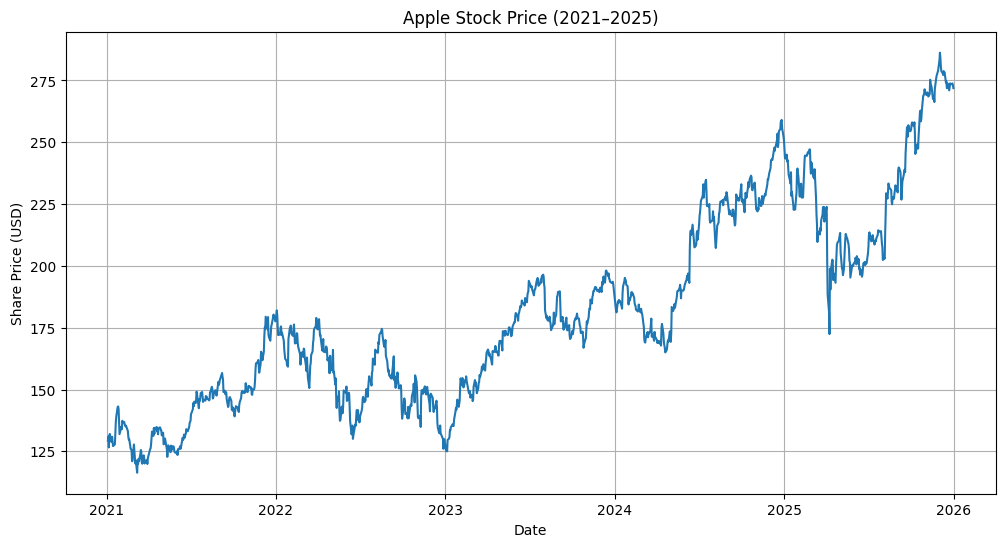

In [40]:
# ============================================================
# CELL 30 — APPLE STOCK PRICE TREND
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    price_df["date"],
    price_df["close"]
)

plt.title("Apple Stock Price (2021–2025)")
plt.xlabel("Date")
plt.ylabel("Share Price (USD)")
plt.grid(True)

plt.show()

In [41]:
# ============================================================
# CELL 31 — COMPANY VALUATION DATA
# ============================================================

profile_url = "https://financialmodelingprep.com/stable/profile"

params = {
    "symbol": "AAPL",
    "apikey": FMP_API_KEY
}

response = requests.get(profile_url, params=params)

print("Status code:", response.status_code)

profile_data = response.json()

profile_df = pd.DataFrame(profile_data)

profile_df[
    [
        "symbol",
        "companyName",
        "price",
        "marketCap",
        "beta",
        "lastDividend"
    ]
]

Status code: 200


,symbol,companyName,price,marketCap,beta,lastDividend
0,AAPL,Apple Inc.,319.7,4695547713200,1.086,1.06


In [42]:
# ============================================================
# CELL 32 — VALUATION RATIOS
# ============================================================

current_price = profile_df.loc[0, "price"]
market_cap = profile_df.loc[0, "marketCap"]
beta = profile_df.loc[0, "beta"]

# Use latest fiscal-year data
latest_income = fundamental_df.iloc[-1]
latest_balance = balance_clean_df.iloc[-1]
latest_cashflow = cashflow_clean_df.iloc[-1]

# Approximate valuation ratios
pe_ratio = current_price / latest_income["Diluted EPS"]

price_to_sales = (
    market_cap
    / (latest_income["Revenue ($B)"] * 1_000_000_000)
)

price_to_book = (
    market_cap
    / (latest_balance["Shareholders' Equity ($B)"] * 1_000_000_000)
)

fcf_yield = (
    latest_cashflow["Free Cash Flow ($B)"] * 1_000_000_000
    / market_cap
    * 100
)

valuation_df = pd.DataFrame({
    "Metric": [
        "Share Price",
        "Market Capitalization",
        "P/E Ratio",
        "Price-to-Sales",
        "Price-to-Book",
        "Free Cash Flow Yield",
        "Beta"
    ],
    "Value": [
        current_price,
        market_cap / 1_000_000_000_000,
        pe_ratio,
        price_to_sales,
        price_to_book,
        fcf_yield,
        beta
    ]
})

valuation_df

,Metric,Value
0,Share Price,319.700000
1,Market Capitalization,4.695548
2,P/E Ratio,42.855228
3,Price-to-Sales,11.283008
4,Price-to-Book,63.683123
5,Free Cash Flow Yield,2.103418
6,Beta,1.086000


In [43]:
# ============================================================
# CELL 33 — FUNDAMENTAL SCORE
# ============================================================

latest_fundamentals = fundamental_df.iloc[-1]
previous_fundamentals = fundamental_df.iloc[-2]

score = 0
score_details = []

# Revenue growth
if latest_fundamentals["Revenue Growth (%)"] > 0:
    score += 1
    score_details.append(("Revenue Growth", 1, "Positive"))
else:
    score_details.append(("Revenue Growth", 0, "Negative"))

# Net income growth
if latest_fundamentals["Net Income Growth (%)"] > 0:
    score += 1
    score_details.append(("Net Income Growth", 1, "Positive"))
else:
    score_details.append(("Net Income Growth", 0, "Negative"))

# EPS growth
if latest_fundamentals["EPS Growth (%)"] > 0:
    score += 1
    score_details.append(("EPS Growth", 1, "Positive"))
else:
    score_details.append(("EPS Growth", 0, "Negative"))

# Gross margin improvement
if (
    latest_fundamentals["Gross Margin (%)"]
    > previous_fundamentals["Gross Margin (%)"]
):
    score += 1
    score_details.append(("Gross Margin Improvement", 1, "Improved"))
else:
    score_details.append(("Gross Margin Improvement", 0, "Declined"))

# Operating margin improvement
if (
    latest_fundamentals["Operating Margin (%)"]
    > previous_fundamentals["Operating Margin (%)"]
):
    score += 1
    score_details.append(("Operating Margin Improvement", 1, "Improved"))
else:
    score_details.append(("Operating Margin Improvement", 0, "Declined"))

# Net margin improvement
if (
    latest_fundamentals["Net Margin (%)"]
    > previous_fundamentals["Net Margin (%)"]
):
    score += 1
    score_details.append(("Net Margin Improvement", 1, "Improved"))
else:
    score_details.append(("Net Margin Improvement", 0, "Declined"))

# Debt-to-assets improvement
latest_debt = balance_clean_df.iloc[-1]["Debt-to-Assets (%)"]
previous_debt = balance_clean_df.iloc[-2]["Debt-to-Assets (%)"]

if latest_debt < previous_debt:
    score += 1
    score_details.append(("Debt-to-Assets", 1, "Improved"))
else:
    score_details.append(("Debt-to-Assets", 0, "Worsened"))

# Free cash flow growth
latest_fcf_growth = cashflow_clean_df.iloc[-1]["FCF Growth (%)"]

if latest_fcf_growth > 0:
    score += 1
    score_details.append(("FCF Growth", 1, "Positive"))
else:
    score_details.append(("FCF Growth", 0, "Negative"))

score_df = pd.DataFrame(
    score_details,
    columns=["Metric", "Points", "Result"]
)

print(f"Fundamental Score: {score}/8")

score_df

Fundamental Score: 7/8


,Metric,Points,Result
0,Revenue Growth,1,Positive
1,Net Income Growth,1,Positive
2,EPS Growth,1,Positive
3,Gross Margin Improvement,1,Improved
4,Operating Margin Improvement,1,Improved
5,Net Margin Improvement,1,Improved
6,Debt-to-Assets,1,Improved
7,FCF Growth,0,Negative


In [44]:
# ============================================================
# CELL 34 — FINAL FUNDAMENTAL SUMMARY
# ============================================================

print("=" * 60)
print("APPLE INC. — FUNDAMENTAL ANALYSIS SUMMARY")
print("=" * 60)

print(f"\nLatest Fiscal Year: {int(latest_fundamentals['Fiscal Year'])}")

print("\nPROFITABILITY")
print(f"Revenue: ${latest_fundamentals['Revenue ($B)']:.2f}B")
print(f"Net Income: ${latest_fundamentals['Net Income ($B)']:.2f}B")
print(f"Gross Margin: {latest_fundamentals['Gross Margin (%)']:.2f}%")
print(f"Operating Margin: {latest_fundamentals['Operating Margin (%)']:.2f}%")
print(f"Net Margin: {latest_fundamentals['Net Margin (%)']:.2f}%")

print("\nGROWTH")
print(f"Revenue Growth: {latest_fundamentals['Revenue Growth (%)']:.2f}%")
print(f"Net Income Growth: {latest_fundamentals['Net Income Growth (%)']:.2f}%")
print(f"EPS Growth: {latest_fundamentals['EPS Growth (%)']:.2f}%")

print("\nBALANCE SHEET")
print(f"Current Ratio: {latest_balance['Current Ratio']:.2f}")
print(f"Debt-to-Assets: {latest_balance['Debt-to-Assets (%)']:.2f}%")
print(f"Debt-to-Equity: {latest_balance['Debt-to-Equity']:.2f}")
print(f"Net Debt: ${latest_balance['Net Debt ($B)']:.2f}B")

print("\nCASH FLOW")
print(f"Operating Cash Flow: ${latest_cashflow['Operating Cash Flow ($B)']:.2f}B")
print(f"Free Cash Flow: ${latest_cashflow['Free Cash Flow ($B)']:.2f}B")
print(f"FCF Margin: {latest_cashflow['FCF Margin (%)']:.2f}%")

print("\nVALUATION")
print(f"Share Price: ${current_price:.2f}")
print(f"P/E Ratio: {pe_ratio:.2f}")
print(f"Price-to-Sales: {price_to_sales:.2f}")
print(f"Price-to-Book: {price_to_book:.2f}")
print(f"FCF Yield: {fcf_yield:.2f}%")
print(f"Beta: {beta:.2f}")

print("\nFUNDAMENTAL SCORE")
print(f"{score}/8")

print("=" * 60)

APPLE INC. — FUNDAMENTAL ANALYSIS SUMMARY

Latest Fiscal Year: 2025

PROFITABILITY
Revenue: $416.16B
Net Income: $112.01B
Gross Margin: 46.91%
Operating Margin: 31.97%
Net Margin: 26.92%

GROWTH
Revenue Growth: 6.43%
Net Income Growth: 19.50%
EPS Growth: 22.59%

BALANCE SHEET
Current Ratio: 0.89
Debt-to-Assets: 31.28%
Debt-to-Equity: 1.52
Net Debt: $76.44B

CASH FLOW
Operating Cash Flow: $111.48B
Free Cash Flow: $98.77B
FCF Margin: 23.73%

VALUATION
Share Price: $319.70
P/E Ratio: 42.86
Price-to-Sales: 11.28
Price-to-Book: 63.68
FCF Yield: 2.10%
Beta: 1.09

FUNDAMENTAL SCORE
7/8


In [45]:
# ============================================================
# CELL 35 — EXPORT ANALYSIS TO EXCEL
# ============================================================

output_file = "Apple_Fundamental_Analysis.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:

    fundamental_df.to_excel(
        writer,
        sheet_name="Income Statement",
        index=False
    )

    balance_clean_df.to_excel(
        writer,
        sheet_name="Balance Sheet",
        index=False
    )

    cashflow_clean_df.to_excel(
        writer,
        sheet_name="Cash Flow",
        index=False
    )

    price_df.to_excel(
        writer,
        sheet_name="Stock Prices",
        index=False
    )

    annual_returns.to_excel(
        writer,
        sheet_name="Annual Returns",
        index=False
    )

    valuation_df.to_excel(
        writer,
        sheet_name="Valuation",
        index=False
    )

    score_df.to_excel(
        writer,
        sheet_name="Fundamental Score",
        index=False
    )

print(f"Analysis exported successfully to: {output_file}")

Analysis exported successfully to: Apple_Fundamental_Analysis.xlsx
